In [34]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34885 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34885/status,
Dashboard: http://127.0.0.1:34885/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46779,Workers: 0
Dashboard: http://127.0.0.1:34885/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36157,Total threads: 4
Dashboard: http://127.0.0.1:38713/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:35789,


In [3]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7efd8cd9c040>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [4]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7efd8cd9c040>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [6]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [12]:
client.close()

In [13]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [14]:
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [15]:
# Getting the SO2 first

Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

so2_19_c = ds_19_c["SO2"].weighted(weighted_lat_19_c).mean(dim=["lev", "lat", "lon"]) * K
so2_19_c_max = max(so2_19_c)
so2_19_c_max.values

array(8.80449907)

In [16]:
so2_60tg = ds_60tg["SO2"].weighted(weighted_lat_60tg).mean(dim=["lev", "lat", "lon"]) * K
so2_60tg_max = max(so2_60tg)
so2_22 = ds_22["SO2"].weighted(weighted_lat_22).mean(dim=["lev", "lat", "lon"]) * K
so2_22_max = max(so2_22)
so2_24 = ds_24["SO2"].weighted(weighted_lat_24).mean(dim=["lev", "lat", "lon"]) * K
so2_24_max = max(so2_24)
so2_1825 = ds_1825["SO2"].weighted(weighted_lat_1825).mean(dim=["lev", "lat", "lon"]) * K
so2_1825_max = max(so2_1825)
so2_1825_17tg = ds_1825_17tg["SO2"].weighted(weighted_lat_1825_17tg).mean(dim=["lev", "lat", "lon"]) * K
so2_1825_17tg_max = max(so2_1825_17tg)
so2_1tg = ds_1tg["SO2"].weighted(weighted_lat_1tg).mean(dim=["lev", "lat", "lon"]) * K
so2_1tg_max = max(so2_1tg)
so2_1pr = ds_1pr["SO2"].weighted(weighted_lat_1pr).mean(dim=["lev", "lat", "lon"]) * K
so2_1pr_max = max(so2_1pr)

In [17]:
aod_19_c = ds_19_c["AOD_VIS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
aod_19_c_max = max(aod_19_c)
aod_19_c_max.values

array(0.28654784)

In [18]:
aod_60tg = ds_60tg["AOD_VIS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
aod_60tg_max = max(aod_60tg)
aod_60tg_max.values

array(0.87335083)

In [19]:
aod_22 = ds_22["AOD_VIS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
aod_22_max = max(aod_22)
aod_24 = ds_24["AOD_VIS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
aod_24_max = max(aod_24)
aod_1825 = ds_1825["AOD_VIS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
aod_1825_max = max(aod_1825)
aod_1825_17tg = ds_1825_17tg["AOD_VIS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
aod_1825_17tg_max = max(aod_1825_17tg)
aod_1tg = ds_1tg["AOD_VIS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
aod_1tg_max = max(aod_1tg)
aod_1pr = ds_1pr["AOD_VIS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
aod_1pr_max = max(aod_1pr)

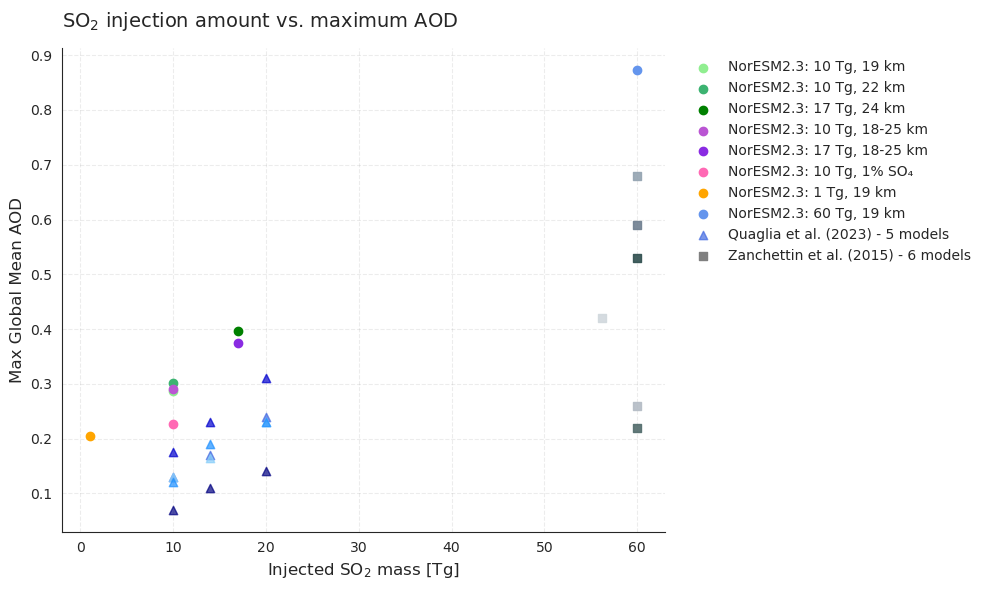

In [ ]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)

# Own runs with NorESM2.3 (circles)
ax.scatter(10, aod_19_c_max, color="lightgreen", label="NorESM2.3: 10 Tg, 19 km", zorder=5)
ax.scatter(10, aod_22_max, color="mediumseagreen", label="NorESM2.3: 10 Tg, 22 km", zorder=5)
ax.scatter(17, aod_24_max, color="green", label="NorESM2.3: 17 Tg, 24 km", zorder=5)
ax.scatter(10, aod_1825_max, color="mediumorchid", label="NorESM2.3: 10 Tg, 18-25 km", zorder=5)
ax.scatter(17, aod_1825_17tg_max, color="blueviolet", label="NorESM2.3: 17 Tg, 18-25 km", zorder=5)
ax.scatter(10, aod_1pr_max, color="hotpink", label="NorESM2.3: 10 Tg, 1% SO₄", zorder=5)
ax.scatter(1, aod_1tg_max, color="orange", label="NorESM2.3: 1 Tg, 19 km", zorder=5)
ax.scatter(60, aod_60tg_max, color="cornflowerblue", label="NorESM2.3: 60 Tg, 19 km", zorder=5)

# Quaglia et al. 2023 (triangles)
quaglia_color = "lightsteelblue"
ax.scatter([10, 14, 20], [0.13, 0.17, 0.24], marker="^", color="royalblue", alpha=0.7, label="Quaglia et al. (2023) - 5 models")
ax.scatter([10, 14, 20], [0.13, 0.165, 0.23], marker="^", color="lightskyblue", alpha=0.7)
ax.scatter([10, 14, 20], [0.175, 0.23, 0.31], marker="^", color="mediumblue", alpha=0.7)
ax.scatter([10, 14, 20], [0.07, 0.11, 0.14], marker="^", color="navy", alpha=0.7)
ax.scatter([10, 14, 20], [0.12, 0.19, 0.23], marker="^", color="dodgerblue", alpha=0.7)

# Zanchettin et al. 2015 (squares) 
zanch_models = [
    {"x": 60,   "y": 0.53, "c": "#2f4f4f", "lab": "UM-UKCA"},     
    {"x": 60,   "y": 0.22, "c": "#526c6c", "lab": "SOCOL"},
    {"x": 60,   "y": 0.59, "c": "#708090", "lab": "MAECHAM"},   
    {"x": 60,   "y": 0.68, "c": "#94a3b1", "lab": "CESM-WACCM"},
    {"x": 60,   "y": 0.26, "c": "#b4bcc5", "lab": "M2D-UPMC"},
    {"x": 56.2, "y": 0.42, "c": "#d1d8dd", "lab": "EVA"}          
]

for m in zanch_models:
    ax.scatter(m["x"], m["y"], marker="s", color=m["c"], alpha=0.9)
ax.scatter([], [], marker="s", color="gray", label="Zanchettin et al. (2015) - 6 models")

ax.set_xlabel("Injected SO$_2$ mass [Tg]", fontsize=12)
ax.set_ylabel("Max Global Mean AOD", fontsize=12)
ax.set_title("SO$_2$ injection amount vs. maximum AOD", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [33]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [35]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))

In [36]:
temp_ctrl = ds_19["TREFHT"].weighted(weighted_lat).mean(dim = ["lat", "lon"]) -273.15
baseline = temp_ctrl.sel(time=slice("1976-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [51]:
temp_19_c = ds_19_c["TREFHT"].weighted(weighted_lat_19_c).mean(dim = ["lat", "lon"]) -273.15
t_anom_19_c = temp_19_c.groupby("time.month") - base
t_anom_19_c_max = min(t_anom_19_c)
t_anom_19_c_max.values

array(-0.2807754)

In [49]:
temp_60tg = ds_60tg["TREFHT"].weighted(weighted_lat_60tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_60tg = temp_60tg.groupby("time.month") - base
t_anom_60tg_max = min(t_anom_60tg)
temp_22 = ds_22["TREFHT"].weighted(weighted_lat_22).mean(dim = ["lat", "lon"]) -273.15
t_anom_22 = temp_22.groupby("time.month") - base
t_anom_22max = min(t_anom_22)
temp_24 = ds_24["TREFHT"].weighted(weighted_lat_24).mean(dim = ["lat", "lon"]) -273.15
t_anom_24 = temp_24.groupby("time.month") - base
t_anom_24_max = min(t_anom_24)
temp_1825 = ds_1825["TREFHT"].weighted(weighted_lat_1825).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825 = temp_1825.groupby("time.month") - base
t_anom_1825_max = min(t_anom_1825)
temp_1825_17tg = ds_1825_17tg["TREFHT"].weighted(weighted_lat_1825_17tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825_17tg = temp_1825_17tg.groupby("time.month") - base
t_anom_1825_17tg_max = min(t_anom_1825_17tg)
temp_1tg = ds_1tg["TREFHT"].weighted(weighted_lat_1tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1tg = temp_1tg.groupby("time.month") - base
t_anom_1tg_max = min(t_anom_1tg)
temp_1pr = ds_1pr["TREFHT"].weighted(weighted_lat_1pr).mean(dim = ["lat", "lon"]) -273.15
t_anom_1pr = temp_1pr.groupby("time.month") - base
t_anom_1pr_max = min(t_anom_1pr)

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3396278/2252861692.py:15: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Largest temp. anomaly [$^\circ$C]", fontsize=12)


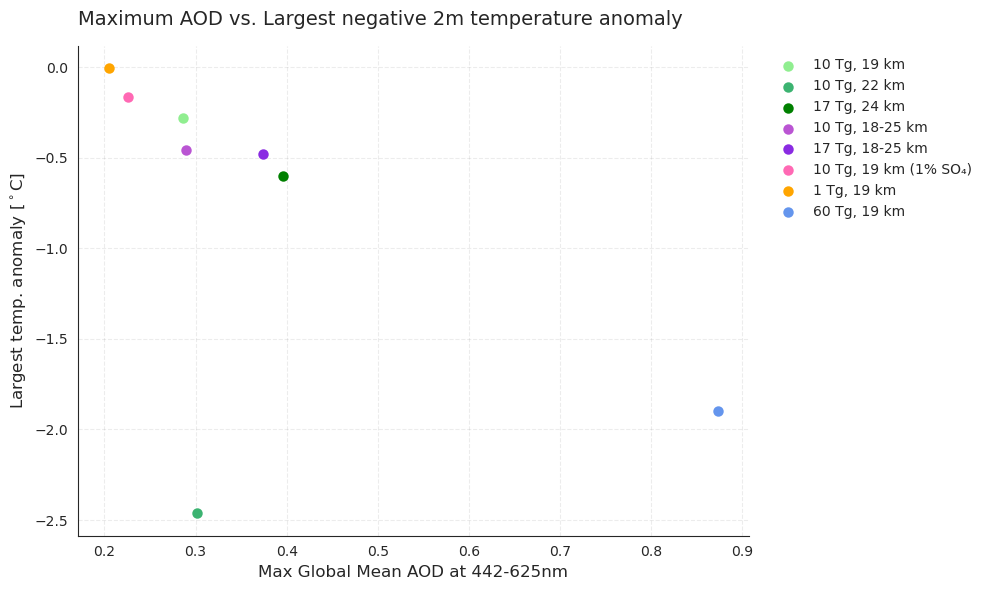

In [52]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)

ax.scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax.scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax.scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
ax.scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax.scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax.scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax.scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
ax.scatter(aod_60tg_max, t_anom_60tg_max,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max Global Mean AOD at 442-625nm", fontsize=12)
ax.set_ylabel("Largest temp. anomaly [$^\circ$C]", fontsize=12)
ax.set_title("Maximum AOD vs. Largest negative 2m temperature anomaly", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3396278/3335678083.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Largest abs. temp. anomaly [$^\circ$C]")


Text(0.5, 1.0, 'Max 2m temp anomaly vs. max AOD')

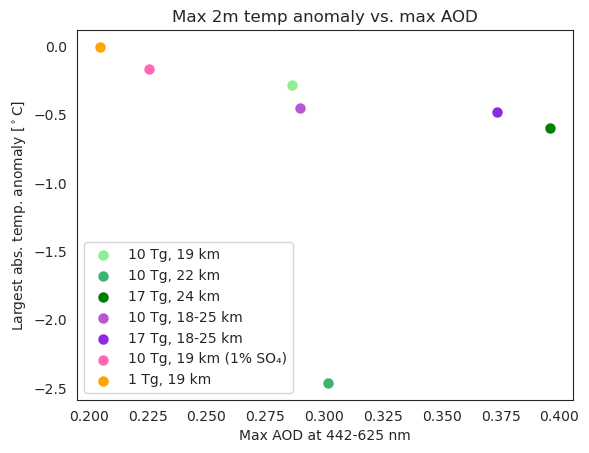

In [40]:
plt.scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")

plt.xlabel("Max AOD at 442-625 nm")
plt.ylabel("Largest abs. temp. anomaly [$^\circ$C]")
plt.legend()
plt.title("Max 2m temp anomaly vs. max AOD")

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3396278/2200690579.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax[1].set_ylabel("Max temperature amomaly [$^\circ$C]")


Text(0.5, 0.98, 'Scatterplots for comparing SO$_2$, AOD, and temperautre anomalies')

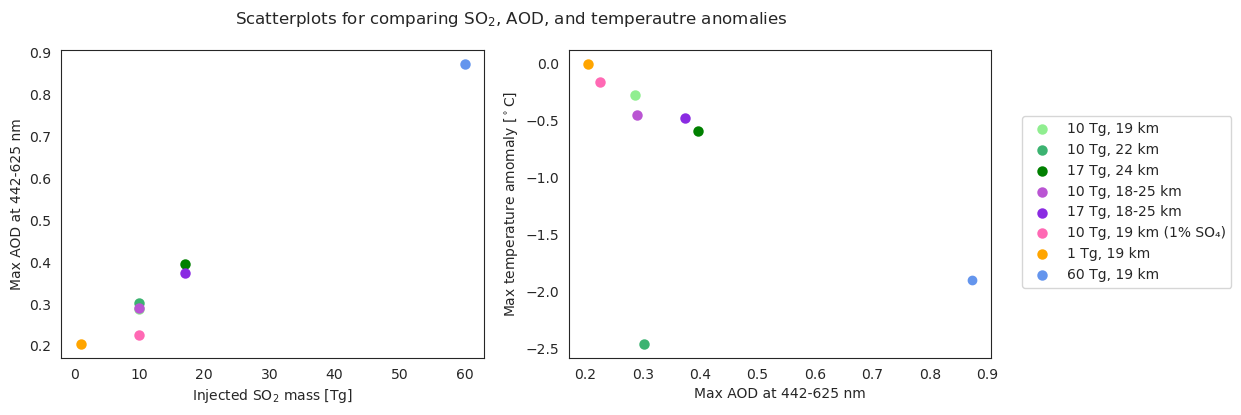

In [41]:
fig, ax = plt.subplots(1,2, figsize=(12, 4), sharex=False)

ax[0].scatter(10, aod_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax[0].scatter(10, aod_22_max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax[0].scatter(17, aod_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
ax[0].scatter(10, aod_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax[0].scatter(17, aod_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax[0].scatter(10, aod_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax[0].scatter(1, aod_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
ax[0].scatter(60, aod_60tg_max,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")
ax[0].set_xlabel("Injected SO$_2$ mass [Tg]")
ax[0].set_ylabel("Max AOD at 442-625 nm")

ax[1].scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5) #,label="10 Tg, 19 km")
ax[1].scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5) #,label="10 Tg, 22 km")
ax[1].scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5) #,label="17 Tg, 24 km")
ax[1].scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5) #,label="10 Tg, 18-25 km")
ax[1].scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5) #,label="17 Tg, 18-25 km")
ax[1].scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5) #, label="10 Tg, 19 km (1% SO₄)")
ax[1].scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5) #, label="1 Tg, 19 km")
ax[1].scatter(aod_60tg_max, t_anom_60tg_max,color="cornflowerblue") #, lw=1.5,label="60 Tg, 19 km ")
ax[1].set_xlabel("Max AOD at 442-625 nm")
ax[1].set_ylabel("Max temperature amomaly [$^\circ$C]")

fig.legend(
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=True
)
#plt.tight_layout
plt.suptitle("Scatterplots for comparing SO$_2$, AOD, and temperautre anomalies")

In [42]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))

In [43]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
p_lev_1tg = tropopause_1tg * 0.01
tropopause_1pr = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
p_lev_1pr = tropopause_1pr * 0.01
tropopause_60tg = ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
p_lev_60tg = tropopause_60tg * 0.01

In [44]:
reff_19_c = ds_19_c["REFF_AERO"].where(ds_19_c["REFF_AERO"]["lev"]<= p_lev_19_c).weighted(weighted_lat_19_c).mean(dim=["lev", "lat", "lon"])
reff_19_c_max = max(reff_19_c)
reff_60tg = ds_60tg["REFF_AERO"].where(ds_60tg["REFF_AERO"]["lev"]<= p_lev_60tg).weighted(weighted_lat_60tg).mean(dim=["lev","lat", "lon"])
reff_60tg_max = max(reff_60tg)
reff_22 = ds_22["REFF_AERO"].where(ds_22["REFF_AERO"]["lev"]<= p_lev_22).weighted(weighted_lat_22).mean(dim=["lev","lat", "lon"])
reff_22_max = max(reff_22)
reff_24 = ds_24["REFF_AERO"].where(ds_24["REFF_AERO"]["lev"]<= p_lev_24).weighted(weighted_lat_24).mean(dim=["lev","lat", "lon"])
reff_24_max = max(reff_24)
reff_1825 = ds_1825["REFF_AERO"].where(ds_1825["REFF_AERO"]["lev"]<= p_lev_1825).weighted(weighted_lat_1825).mean(dim=["lev","lat", "lon"])
reff_1825_max = max(reff_1825)
reff_1825_17tg = ds_1825_17tg["REFF_AERO"].where(ds_1825_17tg["REFF_AERO"]["lev"]<= p_lev_1825_17tg).weighted(weighted_lat_1825_17tg).mean(dim=["lev","lat", "lon"])
reff_1825_17tg_max = max(reff_1825_17tg)
reff_1tg = ds_1tg["REFF_AERO"].where(ds_1tg["REFF_AERO"]["lev"]<= p_lev_1tg).weighted(weighted_lat_1tg).mean(dim=["lev","lat", "lon"])
reff_1tg_max = max(reff_1tg)
reff_1pr = ds_1pr["REFF_AERO"].where(ds_1pr["REFF_AERO"]["lev"]<= p_lev_1pr).weighted(weighted_lat_1pr).mean(dim=["lev","lat", "lon"])
reff_1pr_max = max(reff_1pr)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3396278/2611658366.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


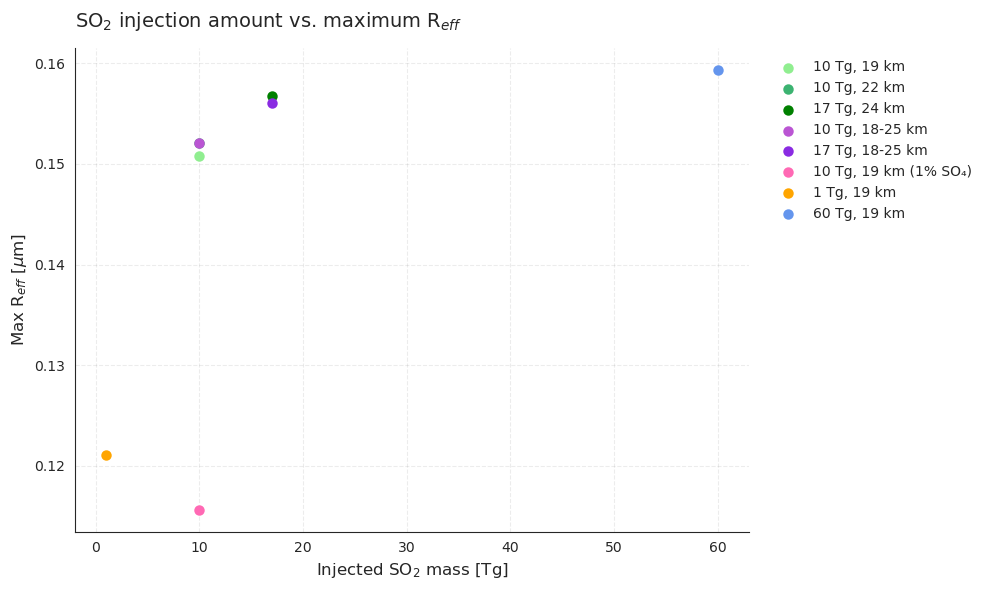

In [47]:
cm_to_mym = 10000

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
ax.scatter(10, reff_19_c_max*cm_to_mym, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax.scatter(10, reff_22_max*cm_to_mym,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax.scatter(17, reff_24_max*cm_to_mym,color="green", lw=1.5,label="17 Tg, 24 km")
ax.scatter(10, reff_1825_max*cm_to_mym,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax.scatter(17, reff_1825_17tg_max*cm_to_mym,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax.scatter(10, reff_1pr_max*cm_to_mym,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax.scatter(1, reff_1tg_max*cm_to_mym, color="orange", lw=1.5, label="1 Tg, 19 km")
ax.scatter(60, reff_60tg_max*cm_to_mym,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Injected SO$_2$ mass [Tg]", fontsize=12)
ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_title("SO$_2$ injection amount vs. maximum R$_{eff}$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3396278/780689156.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


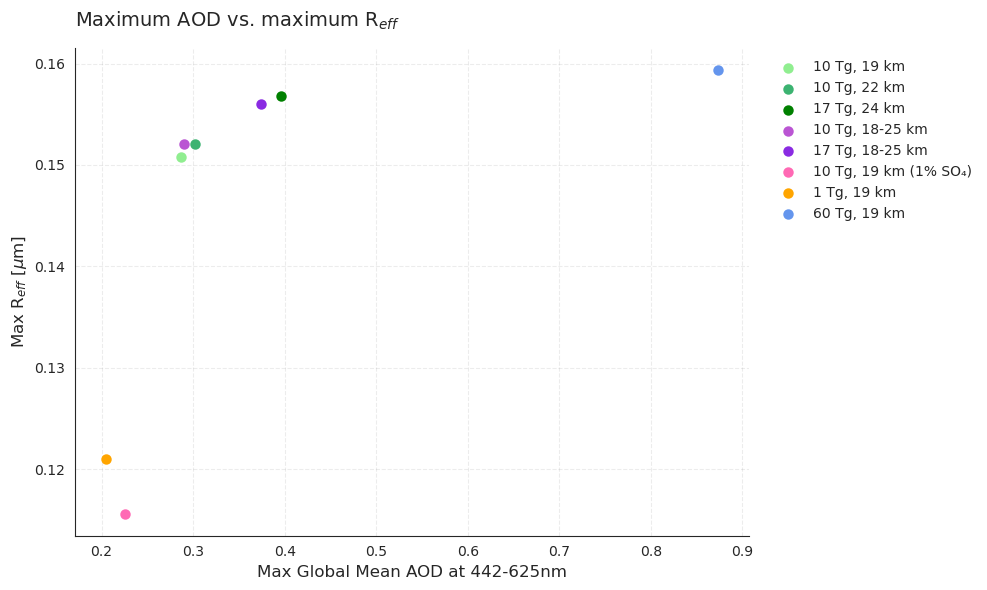

In [48]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(aod_19_c_max, reff_19_c_max*cm_to_mym, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(aod_22_max, reff_22_max*cm_to_mym,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, reff_24_max*cm_to_mym,color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, reff_1825_max*cm_to_mym,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, reff_1825_17tg_max*cm_to_mym,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, reff_1pr_max*cm_to_mym,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, reff_1tg_max*cm_to_mym, color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(aod_60tg_max, reff_60tg_max*cm_to_mym,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")


ax.set_xlabel("Max Global Mean AOD at 442-625nm", fontsize=12)
ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_title("Maximum AOD vs. maximum R$_{eff}$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()